Shape: (260920, 17)

Columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']

Sample:
    match_id  inning           batting_team                 bowling_team  over  \
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
2    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
3    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
4    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   

   ball       batter   bowler  non_striker  batsman_runs  extra_runs  \
0     1   SC Ganguly  P Kumar  BB McCullum             0           1   
1     2  BB McCullum  P Kumar   SC Ganguly             0           0   
2     3  BB McCullum  P Kumar 

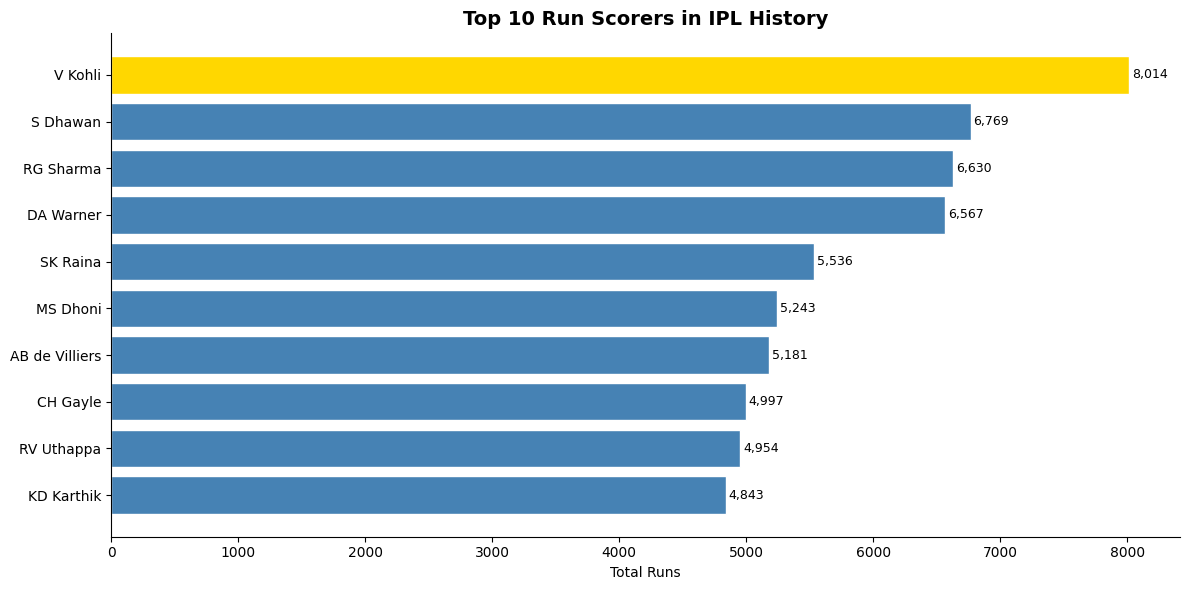

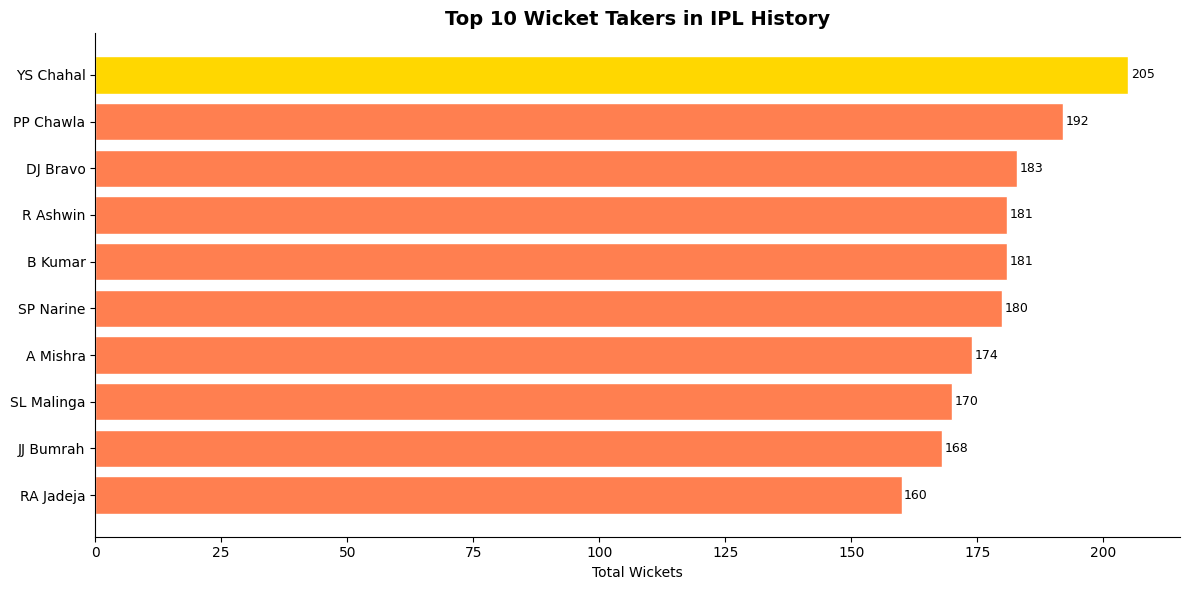

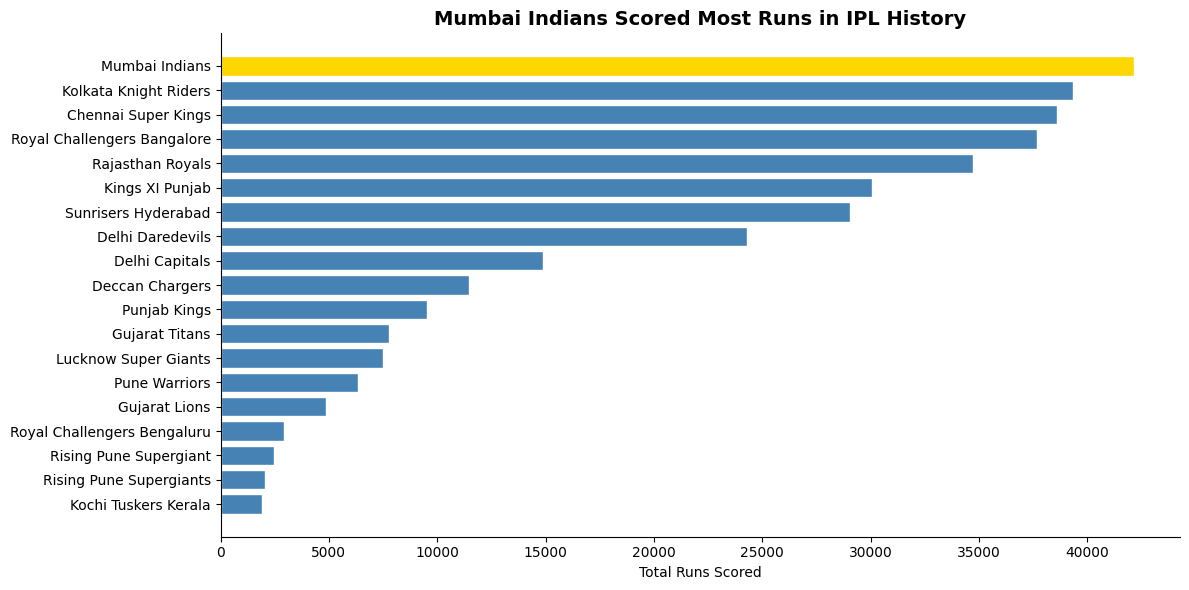

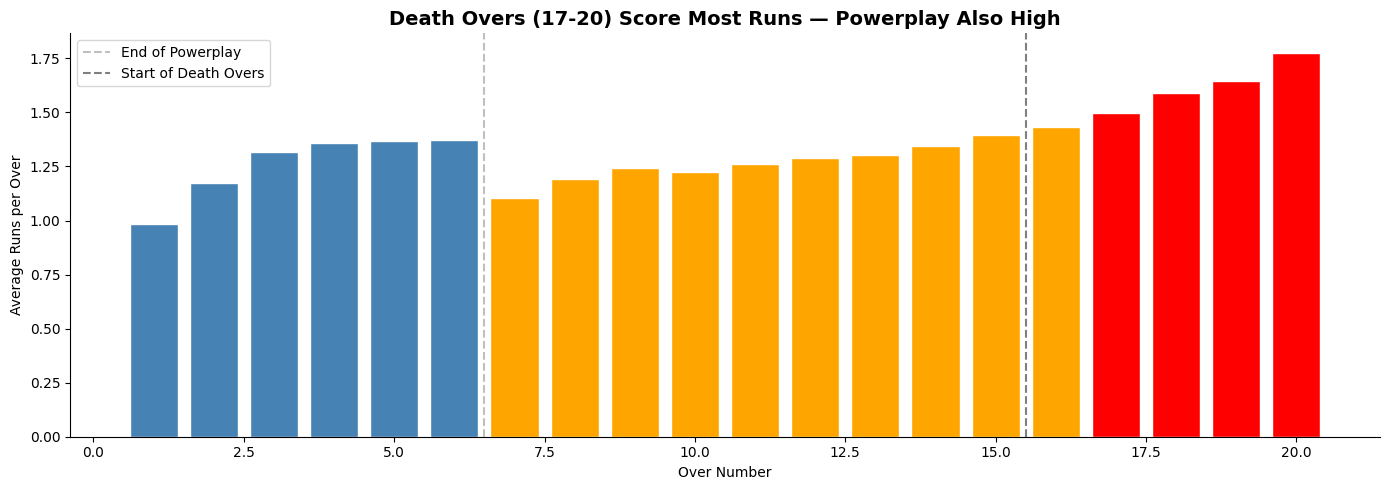

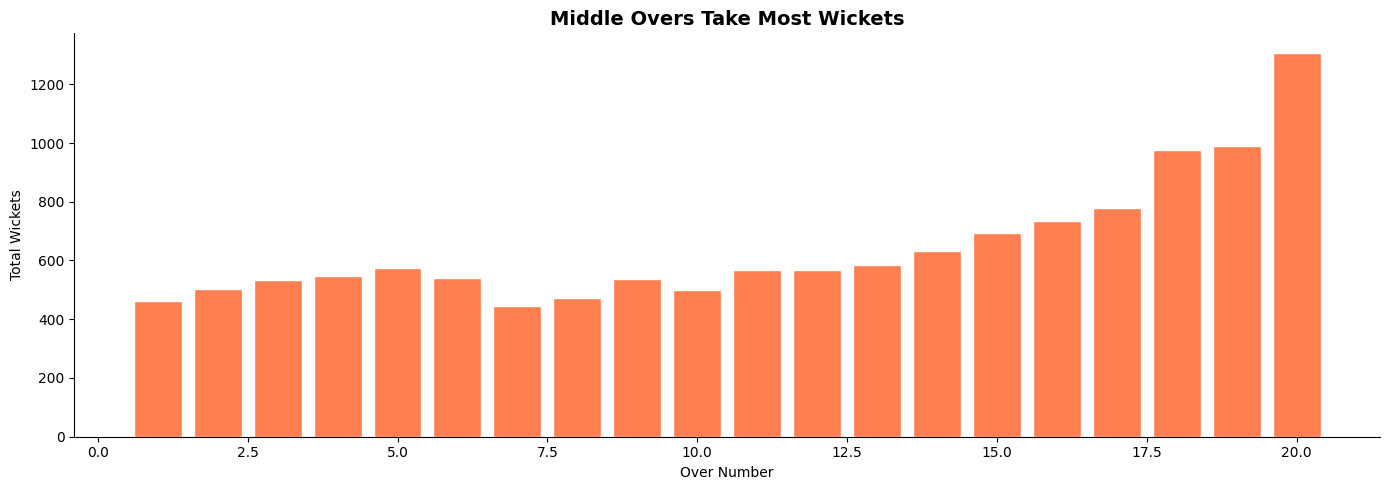

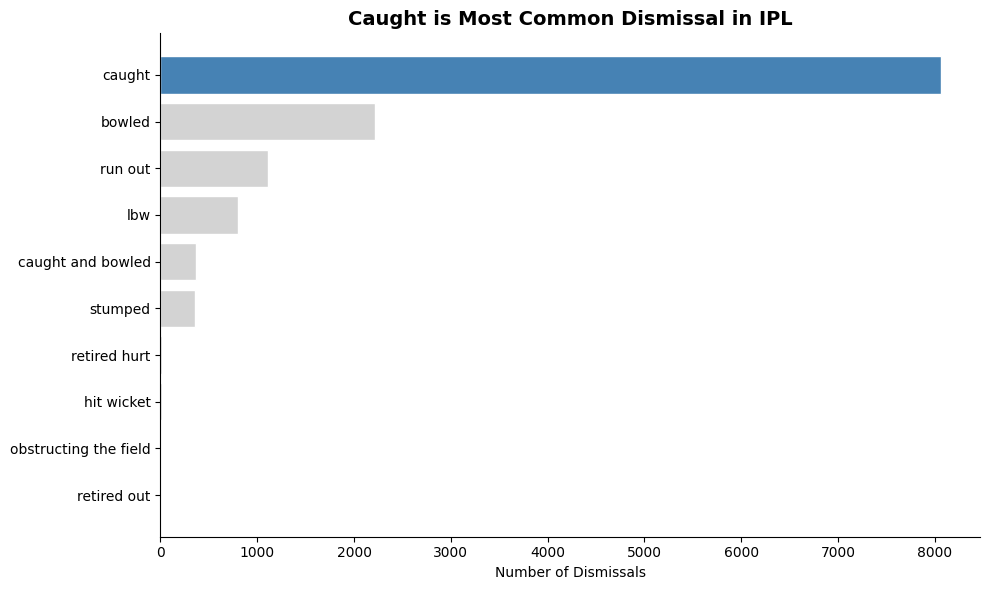

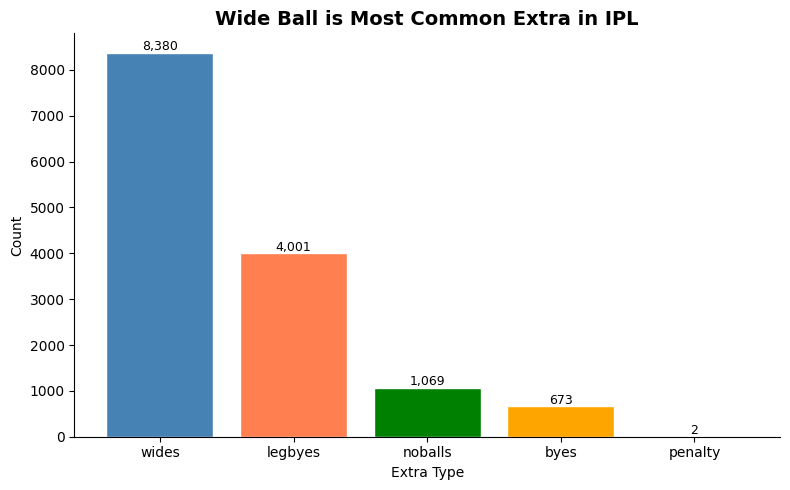


SECTION 7 — KEY INSIGHTS

IPL DATA ANALYSIS — KEY INSIGHTS

INSIGHT 1 — Batting King
Finding: V Kohli is the highest run scorer
         with 8,014 total runs in IPL history
So What: Consistent top-order batsmen win matches
Action:  Franchises must retain proven run scorers at all costs at auction

INSIGHT 2 — Bowling King
Finding: YS Chahal leads all bowlers
         with 205 wickets in IPL history
So What: Match-winning bowlers are as valuable as batsmen
Action:  Teams need 2-3 wicket-taking options to restrict opposition

INSIGHT 3 — Team Dominance
Finding: Mumbai Indians has scored the most total runs in IPL history
So What: Consistent high scoring reflects strong batting lineups
Action:  Building a deep batting order is critical for IPL success

INSIGHT 4 — Over Strategy
Finding: Death overs (17-20) and powerplay (1-6) score the most runs
         Over 20 is the highest scoring over on average
So What: Teams must protect wickets in middle overs to explode in death
Action:  Keep b

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

# ============================================
# LOAD DATA
# ============================================
balls = pd.read_csv("deliveries.csv")

print("Shape:", balls.shape)
print("\nColumns:", balls.columns.tolist())
print("\nSample:\n", balls.head())
print("\nMissing Values:\n", balls.isnull().sum())

# ============================================
# SECTION 1 — DATA CLEANING
# ============================================
print("\n" + "="*50)
print("SECTION 1 — DATA CLEANING")
print("="*50)

print("Before cleaning:", balls.shape)
balls = balls.drop_duplicates().reset_index(drop=True)
print("After cleaning:", balls.shape)
print("Unique matches:", balls["match_id"].nunique())
print("Unique batters:", balls["batter"].nunique())
print("Unique bowlers:", balls["bowler"].nunique())
print("Unique teams:", balls["batting_team"].nunique())

# ============================================
# SECTION 2 — TOP RUN SCORERS
# ============================================
print("\n" + "="*50)
print("SECTION 2 — TOP RUN SCORERS")
print("="*50)

top_scorers = balls.groupby("batter")["batsman_runs"]\
              .sum().sort_values(ascending=False)\
              .head(10).reset_index()
top_scorers.columns = ["batter","total_runs"]
print(top_scorers)

# ============================================
# SECTION 3 — TOP WICKET TAKERS
# ============================================
print("\n" + "="*50)
print("SECTION 3 — TOP WICKET TAKERS")
print("="*50)

dismissals = balls[
    (balls["is_wicket"] == 1) &
    (balls["dismissal_kind"] != "run out")
]

top_bowlers = dismissals.groupby("bowler").size()\
              .sort_values(ascending=False)\
              .head(10).reset_index()
top_bowlers.columns=["bowler","wickets"]
print(top_bowlers)

# ============================================
# SECTION 4 — TEAM ANALYSIS
# ============================================
print("\n" + "="*50)
print("SECTION 4 — TEAM ANALYSIS")
print("="*50)

# Total runs scored per team
team_runs = balls.groupby("batting_team")["total_runs"]\
            .sum().sort_values(ascending=False)\
            .reset_index()
team_runs.columns=["team","total_runs"]
print("Total runs per team:\n", team_runs)

# Economy rate per team (bowling)
team_economy = balls.groupby("bowling_team").agg(
    total_runs=("total_runs","sum"),
    total_overs=("over","count")
).reset_index()
team_economy["economy"]=(team_economy["total_runs"]/
                         (team_economy["total_overs"]/6)).round(2)
team_economy = team_economy.sort_values("economy")
print("\nTeam economy rate: \n", team_economy[["bowling_team","economy"]])

# ============================================
# SECTION 5 — OVER ANALYSIS
# ============================================
print("\n" + "="*50)
print("SECTION 5 — OVER ANALYSIS")
print("="*50)

# Runs per over — which overs score most?
runs_per_over = balls.groupby("over")["total_runs"]\
                .mean().reset_index()
runs_per_over.columns = ["over","avg_runs"]
print("\nAvg runs per over: \n", runs_per_over)

# Wickets per over
wickets_per_over = balls[balls["is_wicket"] == 1]\
                   .groupby("over").size().reset_index()
wickets_per_over.columns=["over","wickets"]
print("\nWickets per over: \n", wickets_per_over)

# ============================================
# SECTION 6 — VISUALIZATIONS
# ============================================
print("\n" + "="*50)
print("SECTION 6 — VISUALIZATIONS")
print("="*50)

# --- Chart 1: Top 10 Run Scorers ---
fig, ax = plt.subplots(figsize=(12,6))
colors = ["gold" if b == top_scorers.iloc[0]["batter"]
          else "steelblue" for b in top_scorers["batter"]]
bars = ax.barh(top_scorers["batter"][::-1],
               top_scorers["total_runs"][::-1],
               color=colors[::-1], edgecolor="white")
ax.set_title("Top 10 Run Scorers in IPL History",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Total Runs")
for bar in bars:
    width = bar.get_width()
    ax.text(width+20, bar.get_y()+bar.get_height()/2,
            f"{int(width):,}", va="center", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("top_scorers.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Chart 2: Top 10 Wicket Takers ---
fig, ax = plt.subplots(figsize=(12,6))
colors = ["gold" if b == top_bowlers.iloc[0]["bowler"]
          else "coral" for b in top_bowlers["bowler"]]
bars = ax.barh(top_bowlers["bowler"][::-1],
               top_bowlers["wickets"][::-1],
               color=colors[::-1], edgecolor="white")
ax.set_title("Top 10 Wicket Takers in IPL History",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Total Wickets")
for bar in bars:
    width = bar.get_width()
    ax.text(width+0.5, bar.get_y()+bar.get_height()/2,
            str(int(width)), va="center", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("top_bowlers.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Chart 3: Total Runs by Team ---
fig, ax = plt.subplots(figsize=(12,6))
colors = ["gold" if t == team_runs.iloc[0]["team"]
          else "steelblue" for t in team_runs["team"]]
ax.barh(team_runs["team"][::-1],
        team_runs["total_runs"][::-1],
        color=colors[::-1], edgecolor="white")
ax.set_title(f"{team_runs.iloc[0]['team']} Scored Most Runs in IPL History",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Total Runs Scored")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("team_runs.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Chart 4: Average Runs per Over ---
fig, ax = plt.subplots(figsize=(14,5))
colors = ["red" if o >= 16 else "orange" if o >= 6
          else "steelblue" for o in runs_per_over["over"]]
ax.bar(runs_per_over["over"]+1,
       runs_per_over["avg_runs"],
       color=colors, edgecolor="white")
ax.set_title("Death Overs (17-20) Score Most Runs — Powerplay Also High",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Over Number")
ax.set_ylabel("Average Runs per Over")
ax.axvline(6.5, color="gray", linestyle="--", alpha=0.5,
           label="End of Powerplay")
ax.axvline(15.5, color="black", linestyle="--", alpha=0.5,
           label="Start of Death Overs")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("runs_per_over.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Chart 5: Wickets per Over ---
fig, ax = plt.subplots(figsize=(14,5))
ax.bar(wickets_per_over["over"]+1,
       wickets_per_over["wickets"],
       color="coral", edgecolor="white")
ax.set_title("Middle Overs Take Most Wickets",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Over Number")
ax.set_ylabel("Total Wickets")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("wickets_per_over.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Chart 6: Dismissal types ---
dismissal_types = balls[balls["is_wicket"]==1]\
                  ["dismissal_kind"].value_counts().reset_index()
dismissal_types.columns = ["type","count"]

fig, ax = plt.subplots(figsize=(10,6))
colors_d = ["steelblue" if d == dismissal_types.iloc[0]["type"]
            else "lightgray" for d in dismissal_types["type"]]
ax.barh(dismissal_types["type"][::-1],
        dismissal_types["count"][::-1],
        color=colors_d[::-1], edgecolor="white")
ax.set_title(f"Caught is Most Common Dismissal in IPL",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Dismissals")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("dismissal_types.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Chart 7: Extras type distribution ---
extras = balls[balls["extras_type"].notna()]\
         ["extras_type"].value_counts().reset_index()
extras.columns = ["type","count"]

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(extras["type"], extras["count"],
       color=["steelblue","coral","green","orange"],
       edgecolor="white")
ax.set_title("Wide Ball is Most Common Extra in IPL",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Extra Type")
ax.set_ylabel("Count")
for i, v in enumerate(extras["count"]):
    ax.text(i, v+50, f"{v:,}", ha="center", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("extras.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Chart 8: Plotly — Top scorers interactive ---
fig = px.bar(top_scorers,
             x="total_runs",
             y="batter",
             orientation="h",
             title="Top 10 IPL Run Scorers — Interactive",
             color="total_runs",
             color_continuous_scale="Blues",
             text="total_runs")
fig.update_traces(texttemplate="%{text:,}", textposition="outside")
fig.update_layout(height=500, showlegend=False,
                  yaxis=dict(categoryorder="total ascending"))
fig.show()

# --- Chart 9: Plotly — Economy rate by team ---
fig = px.bar(team_economy.head(10),
             x="bowling_team",
             y="economy",
             title="Team Economy Rates — Lower is Better for Bowling",
             color="economy",
             color_continuous_scale="RdYlGn_r",
             text="economy")
fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")
fig.update_layout(height=500, showlegend=False)
fig.show()

# --- Chart 10: Full Plotly Dashboard ---
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        "Top 5 Run Scorers",
        "Top 5 Wicket Takers",
        "Avg Runs per Over",
        "Team Total Runs"
    ]
)

fig.add_trace(
    go.Bar(x=top_scorers.head(5)["batter"],
           y=top_scorers.head(5)["total_runs"],
           marker_color="steelblue", name="Runs"),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=top_bowlers.head(5)["bowler"],
           y=top_bowlers.head(5)["wickets"],
           marker_color="coral", name="Wickets"),
    row=1, col=2
)

fig.add_trace(
    go.Bar(x=runs_per_over["over"]+1,
           y=runs_per_over["avg_runs"],
           marker_color="green", name="Avg Runs"),
    row=2, col=1
)

fig.add_trace(
    go.Bar(x=team_runs["team"],
           y=team_runs["total_runs"],
           marker_color="purple", name="Team Runs"),
    row=2, col=2
)

fig.update_layout(
    title_text="IPL Analytics Dashboard",
    height=700,
    showlegend=False
)
fig.show()

# ============================================
# SECTION 7 — BUSINESS INSIGHTS
# ============================================
print("\n" + "="*50)
print("SECTION 7 — KEY INSIGHTS")
print("="*50)

top_scorer_name = top_scorers.iloc[0]["batter"]
top_scorer_runs = top_scorers.iloc[0]["total_runs"]
top_bowler_name = top_bowlers.iloc[0]["bowler"]
top_bowler_wkts = top_bowlers.iloc[0]["wickets"]
top_team_name   = team_runs.iloc[0]["team"]
best_economy    = team_economy.iloc[0]["bowling_team"]
peak_over       = runs_per_over.loc[runs_per_over["avg_runs"].idxmax(),"over"]+1

print(f"""
IPL DATA ANALYSIS — KEY INSIGHTS
===================================

INSIGHT 1 — Batting King
Finding: {top_scorer_name} is the highest run scorer
         with {top_scorer_runs:,} total runs in IPL history
So What: Consistent top-order batsmen win matches
Action:  Franchises must retain proven run scorers at all costs at auction

INSIGHT 2 — Bowling King
Finding: {top_bowler_name} leads all bowlers
         with {top_bowler_wkts} wickets in IPL history
So What: Match-winning bowlers are as valuable as batsmen
Action:  Teams need 2-3 wicket-taking options to restrict opposition

INSIGHT 3 — Team Dominance
Finding: {top_team_name} has scored the most total runs in IPL history
So What: Consistent high scoring reflects strong batting lineups
Action:  Building a deep batting order is critical for IPL success

INSIGHT 4 — Over Strategy
Finding: Death overs (17-20) and powerplay (1-6) score the most runs
         Over {int(peak_over)} is the highest scoring over on average
So What: Teams must protect wickets in middle overs to explode in death
Action:  Keep best finishers for overs 17-20 — maximize those overs

INSIGHT 5 — Dismissal Pattern
Finding: Caught dismissals account for majority of wickets in IPL
So What: Aerial shots in powerplay and death overs are high risk
Action:  Teams should coach batsmen on shot selection in crucial phases

INSIGHT 6 — Economy Matters
Finding: {best_economy} has the best bowling economy rate
So What: Containing runs is as important as taking wickets in T20
Action:  Teams need economical bowlers especially in middle overs 7-15
""")

# ============================================
# SECTION 8 — SUMMARY
# ============================================
print("="*50)
print("SECTION 8 — PROJECT SUMMARY")
print("="*50)
print(f"Total deliveries analyzed: {len(balls):,}")
print(f"Total matches covered: {balls['match_id'].nunique()}")
print(f"Total teams: {balls['batting_team'].nunique()}")
print(f"Total batters: {balls['batter'].nunique()}")
print(f"Total bowlers: {balls['bowler'].nunique()}")
print(f"Total wickets: {int(balls['is_wicket'].sum()):,}")
print(f"Total runs scored: {balls['batsman_runs'].sum():,}")